# Plot pcFVA Results

In [1]:
from pathlib import Path
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rbc_gem_utils import FluxOptimizationViz, CorrelationsViz, FluxOptimizationAggregator

In [2]:
model_id = "RBC3P_expanded"
dataset_name = "RBComics_G6PD"
data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"
pcfva_results_dirpath = dataset_path / "pcFVA"
corr_results_dirpath = dataset_path / "correlations"
df_pcfva_all_filename = pcfva_results_dirpath / f"{model_id}_PC_FVAresults_ALL.tsv"
model_filename = pcmodel_dirpath / f"{model_id}.xml"
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
correlations2_dirpath = dataset_path / "correlations2"
flux_plots_path = dataset_path / "flux_plots"

print(results_path)
print(pcmodel_dirpath)
print(dataset_path)
print(dataset_models_dirpath)
print(pcfva_results_dirpath)
print(corr_results_dirpath)
print(df_pcfva_all_filename)
print(model_filename)
print(pcmodel_filename)
print(correlations2_dirpath)
print(flux_plots_path)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcmodels
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA\RBC3P_expanded_PC_FVAresults_ALL.tsv
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded.xml
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded_PC.xml
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots


D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2\df_flux_abundance_correlation.csv
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\correlates_flux_abundance.svg


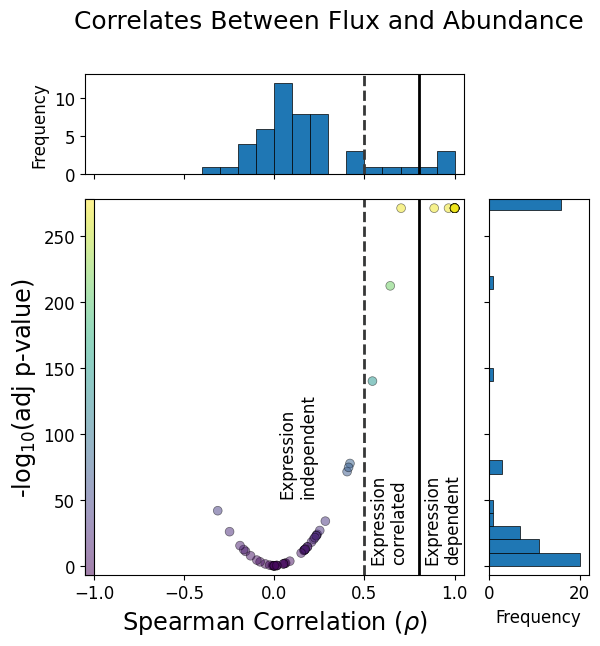

In [3]:
df_flux_abundance_correlation_filename = (
    correlations2_dirpath / "df_flux_abundance_correlation.csv"
)
plot_flux_abundance_correlations_filename = flux_plots_path / "correlates_flux_abundance.svg"
print(df_flux_abundance_correlation_filename)
print(plot_flux_abundance_correlations_filename)
df_flux_abundance_correlation = pd.read_csv(df_flux_abundance_correlation_filename)
correlations_viz = CorrelationsViz(df_flux_abundance_correlation_filename=df_flux_abundance_correlation_filename)
correlations_viz.plot_flux_abundance_correlations(save_filename=plot_flux_abundance_correlations_filename);
# plt.close()

In [4]:
plt.close()

### Donut charts of subsystems

Look at categories and subsystems here: [KEGG pathways](https://www.kegg.jp/kegg/pathway.html) Look at "category" in df_pathways.

In [5]:
df_flux_abundance_correlation["category"].unique()

array(['Nucleotide metabolism', 'Transport reactions',
       'Metabolism of cofactors and vitamins', 'Carbohydrate metabolism',
       'Reactive species', 'Metabolism of other amino acids'],
      dtype=object)

In [6]:
def map_categories_to_colors(categories):
    color_for_category = {
        "Nucleotide metabolism": "#332288",
        "Transport reactions": "#117733",
        "Metabolism of cofactors and vitamins": "#44AA99",
        "Carbohydrate metabolism": "#88CCEE",
        "Reactive species": "#999933",
        "Metabolism of other amino acids": "#DDCC77",
    }
    return [color_for_category[category] for category in categories]

In [7]:
dependent_reaction_categories_plot_filename = (
    flux_plots_path / "dependent_reaction_categories.svg"
)
print(dependent_reaction_categories_plot_filename)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\dependent_reaction_categories.svg


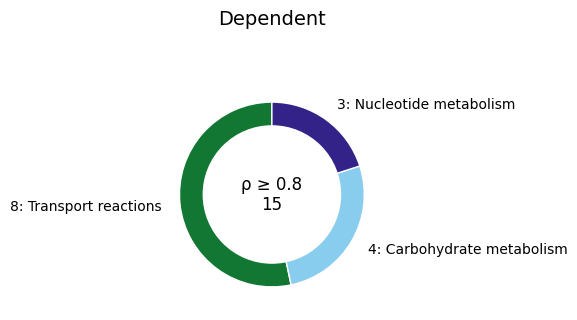

In [8]:
correlations_viz.plot_donuts_of_categories_by_abundance_dependence(
    abundance_dependence="Dependent",
    figsize=(3, 3),
    center_title="ρ ≥ 0.8",
    save_filename=dependent_reaction_categories_plot_filename
);

In [9]:
correlated_reaction_categories_plot_filename = (
    flux_plots_path / "correlated_reaction_categories.svg"
)
print(correlated_reaction_categories_plot_filename)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\correlated_reaction_categories.svg


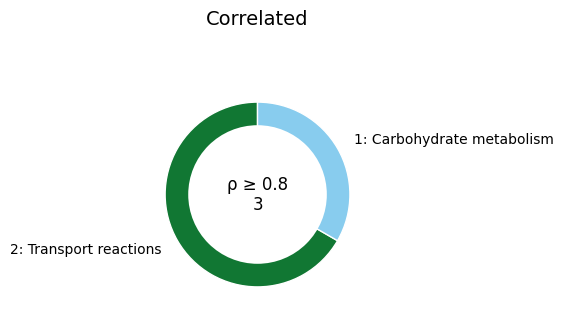

In [10]:
correlations_viz.plot_donuts_of_categories_by_abundance_dependence(
    abundance_dependence="Correlated",
    figsize=(3, 3),
    center_title="ρ ≥ 0.8",
    save_filename=correlated_reaction_categories_plot_filename
);

In [11]:
independent_reaction_categories_plot_filename = (
    flux_plots_path / "independent_reaction_categories.svg"
)
print(independent_reaction_categories_plot_filename)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\independent_reaction_categories.svg


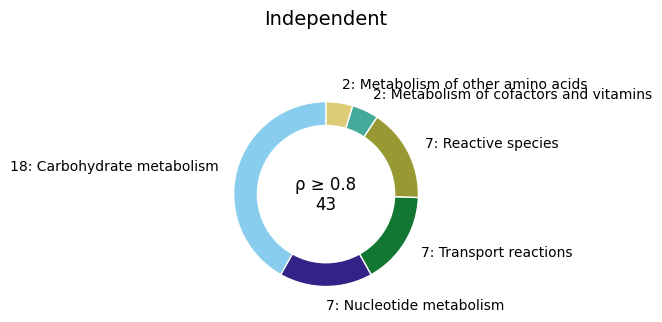

In [12]:
correlations_viz.plot_donuts_of_categories_by_abundance_dependence(
    abundance_dependence="Independent",
    figsize=(3, 3),
    center_title="ρ ≥ 0.8",
    save_filename=independent_reaction_categories_plot_filename
);

TODO: Make pathway map. Use Escher and instead of edge weights being fluxes, correlation coefficients.

### Gene reaction counts horizontal bar charts

In [13]:
df_gene_reaction_count_filename = correlations2_dirpath / "df_gene_reaction_count.csv"
df_gene_reaction_count = pd.read_csv(df_gene_reaction_count_filename)
df_gene_reaction_count

,abundance_dependence,genes,category,reactions
0,Correlated,BSG;EMB;SLC16A1;SLC16A7,Transport reactions,2
1,Correlated,ENO1;ENO2;ENO3,Carbohydrate metabolism,1
2,Dependent,NT5C2,Nucleotide metabolism,2
3,Dependent,AMPD3,Nucleotide metabolism,1
4,Dependent,AQP1,Transport reactions,1
5,Dependent,AQP1;AQP3,Transport reactions,1
6,Dependent,AQP1;AQP3;RHAG;RHCE;RHD,Transport reactions,1
7,Dependent,AQP1;RHAG;RHCE;RHD,Transport reactions,1
8,Dependent,ATP2B1;ATP2B4,Transport reactions,1
9,Dependent,CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;T...,Transport reactions,1


In [14]:
def make_gene_reaction_count_plot(df, abundance_dependence, **kwargs):
    df1 = df[df["abundance_dependence"] == abundance_dependence][
        ["reactions", "genes", "category"]
    ]
    df1.set_index("genes", inplace=True)
    fig, ax = plt.subplots(nrows=1, ncols=1, **kwargs)
    ax.barh(
        df1.index, df1["reactions"], color=map_categories_to_colors(df1["category"])
    )

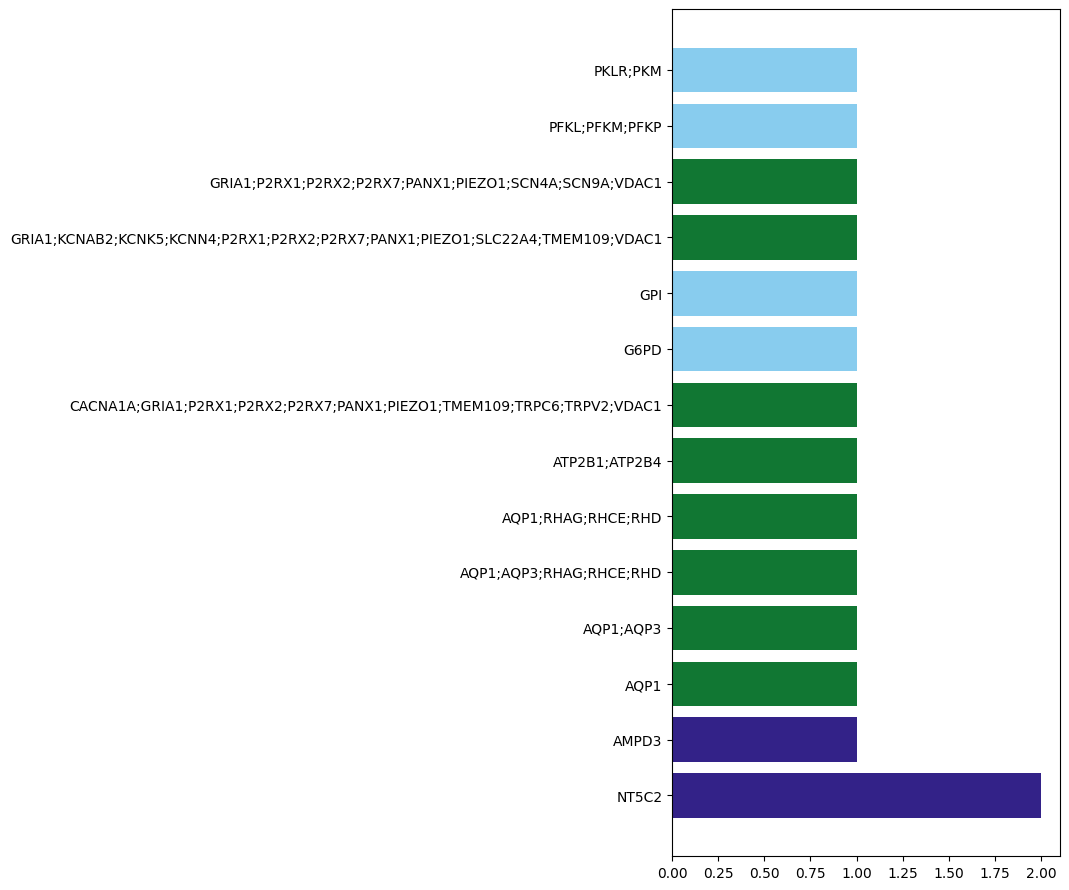

In [15]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Dependent", figsize=(5, 11))

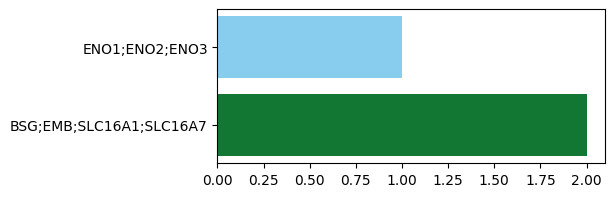

In [16]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Correlated", figsize=(5, 2))

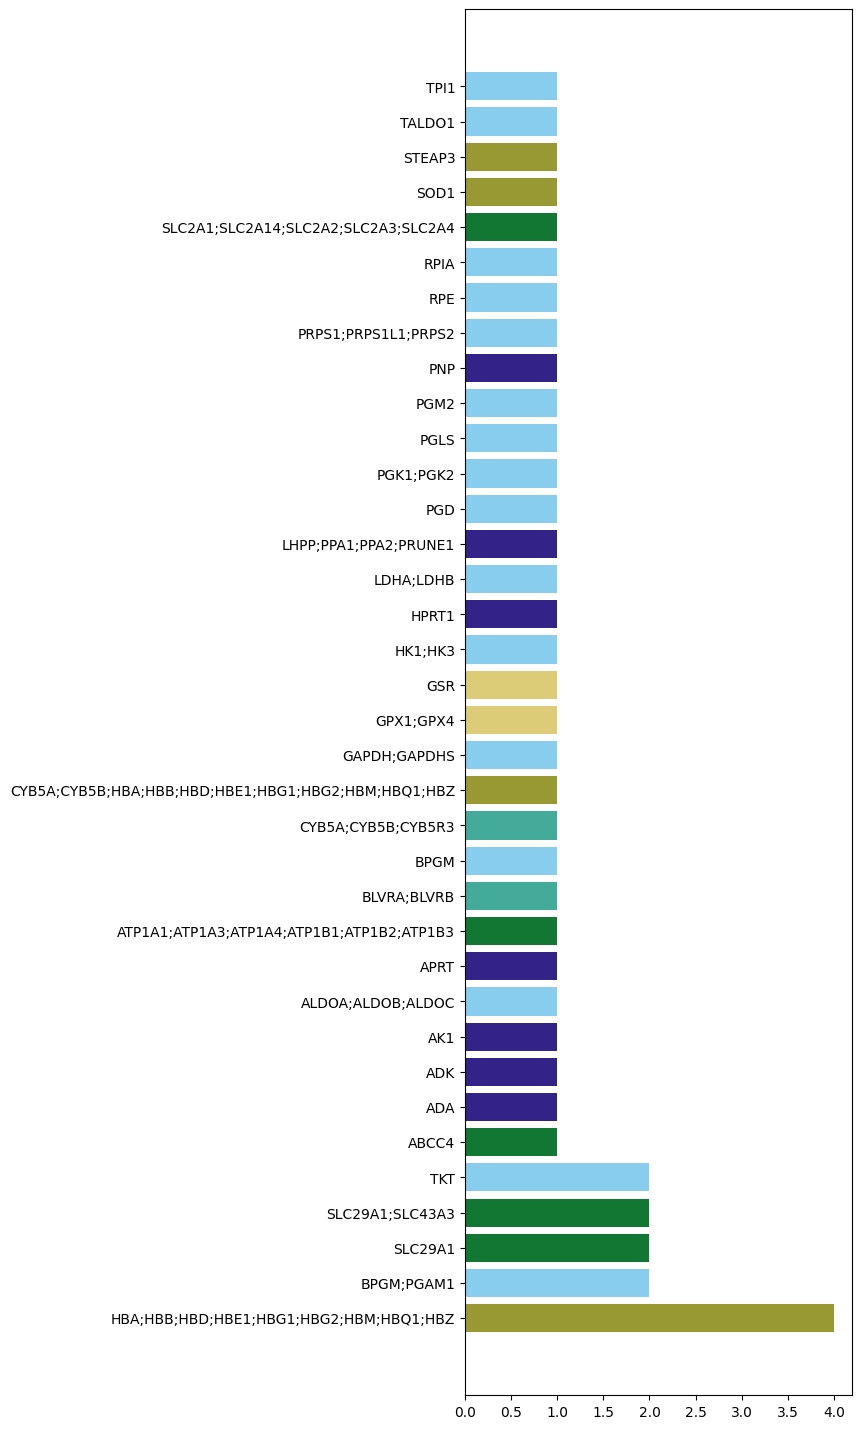

In [17]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Independent", figsize=(5, 18))

### Plot solution space of by day, reaction, and G6PD_allele

In [18]:
print(correlations2_dirpath)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2


In [19]:
df_pcfva_alleles_filename = correlations2_dirpath / "df_pcfva_alleles.csv"
flux_optimization_viz = FluxOptimizationViz(
    model_filename=model_filename, df_pcfva_alleles_filename=df_pcfva_alleles_filename
)

Set parameter Username


In [20]:
for (
    subsystem,
    reaction_list,
) in flux_optimization_viz.get_subsystem_reactions_dict().items():
    joined_reaction_list = ", ".join(reaction_list)
    print(subsystem, len(reaction_list), joined_reaction_list)

Purine metabolism 9 ADA, ADK1, ADNK1, ADPT, AMPDA, HXPRT, NTDIMP, NTDAMP, PUNP5
Transport, extracellular 20 ADEt, ADNt, CA2t, CO2t, H2O2t, H2Ot, HYXNt, Ht, INSt, L_LACt2, NaKt, O2t, NAt, PIt, PYRt2, CAATPS1, GLC_Dt, Kt1, NH4t, BILRUBABCte
Glycolysis / Gluconeogenesis 13 DPGM, DPGase, ENO, FBA, HEX1, GAPD, LDH_L, PFK, PGI, PGK, PGM, PYK, TPI
Pentose phosphate pathway 10 G6PDH2, GND, PGL, PPM, PRPPS, RPE, RPI, TALA, TKT1, TKT2
Glutathione metabolism 2 GTHOy, GTHP
Nucleotide metabolism 2 PPA, NTPA
Hemoglobin binding and degradation 5 HB23DPGB, HBO2B1, HBO2B2, METHBCYTBR, OXYHBAOX
Nicotinate and nicotinamide metabolism 1 FCYTOB5OXR
Reactive species formation and detoxification 4 SPODM, FE2O2OX, FE3RD, FE2H2O2X
Pseudoreactions 24 EX_ca2_e, EX_co2_e, EX_glc__D_e, EX_h_e, EX_h2o_e, EX_h2o2_e, EX_ade_e, EX_hxan_e, EX_adn_e, EX_ins_e, EX_k_e, EX_lac__L_e, EX_na1_e, EX_nh4_e, EX_o2_e, EX_pi_e, EX_pyr_e, SK_hb4_23dpg_c, SK_oxyhb_c, SK_hb_hco2_c, SK_na1_c, SK_k_c, SK_ca2_c, EX_bilirub_e
Porphyrin 

In [21]:
flux_group_glycolysis = [
    ["HEX1", "PGI", "PFK", "FBA", "TPI"],
    ["GAPD", "PGK", "PGM", "ENO", "PYK"],
    ["LDH_L", "DPGM", "DPGase", "", "NaKt"],
]

flux_group_ppp = [
    ["G6PDH2", "PGL", "GND", "RPE", "RPI"],
    ["TKT1", "TALA", "TKT2", "PRPPS", "NaKt"],
]

flux_group_purine_metabolism = [
    ["ADPT", "ADK1", "ADNK1", "ADA", "AMPDA"],
    ["NTDIMP", "NTDAMP", "PUNP5", "HXPRT", "NaKt"],
]

flux_group_interesting_reactions = [
    ["G6PDH2", "PGL", "GND"], 
    ["PGI", "", ""]
]

In [22]:
flux_optimization_viz.iterate_make_optimum_min_max_plots(
    fluxes_to_plot=flux_group_glycolysis, flux_plots_path=flux_plots_path
)
flux_optimization_viz.iterate_make_optimum_min_max_plots(
    fluxes_to_plot=flux_group_ppp, flux_plots_path=flux_plots_path
)
flux_optimization_viz.iterate_make_optimum_min_max_plots(
    fluxes_to_plot=flux_group_purine_metabolism, flux_plots_path=flux_plots_path
);

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\HEX1_day_10.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\HEX1_day_23.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\HEX1_day_42.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGI_day_10.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGI_day_23.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGI_day_42.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PFK_day_10.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PFK_day_23.svg saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PFK_day_42.svg saved
D:\Proj

### Combine these plots onto one plot with small multiples

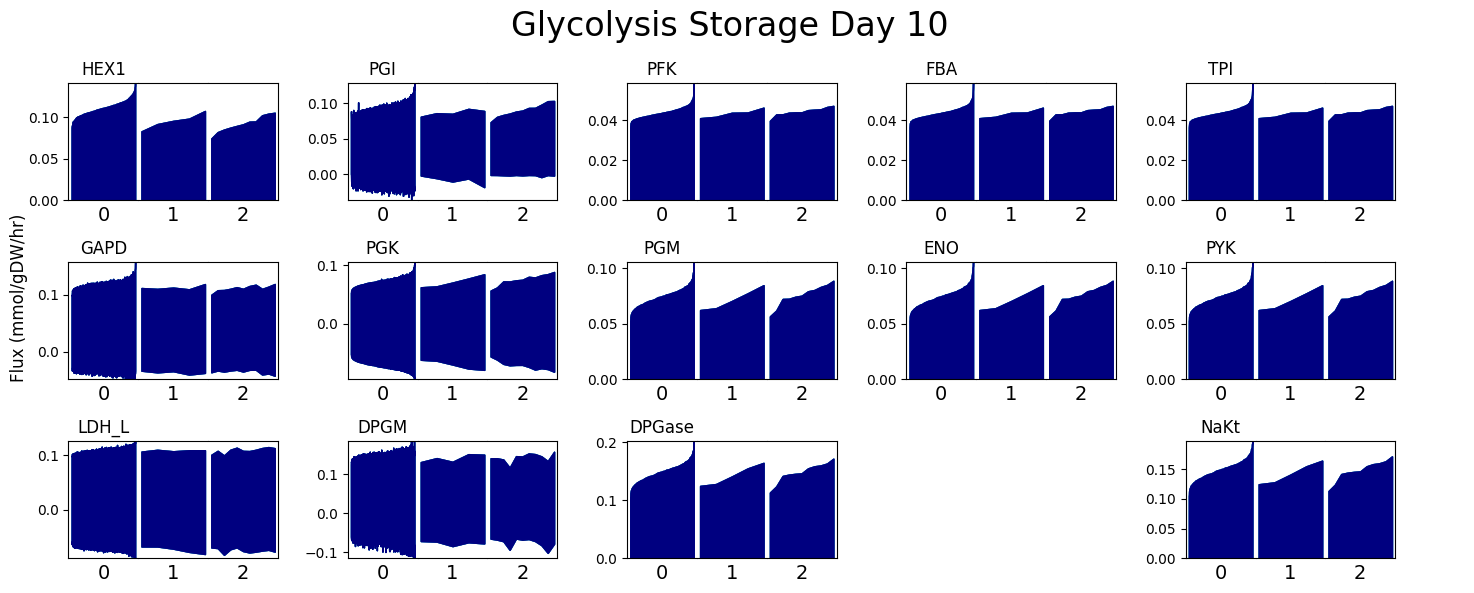

In [23]:
flux_optimization_viz.alleles_day_flux_small_multiples(
    10, flux_group_glycolysis, "Glycolysis", figsize=(15, 6), flux_plots_path=flux_plots_path
);

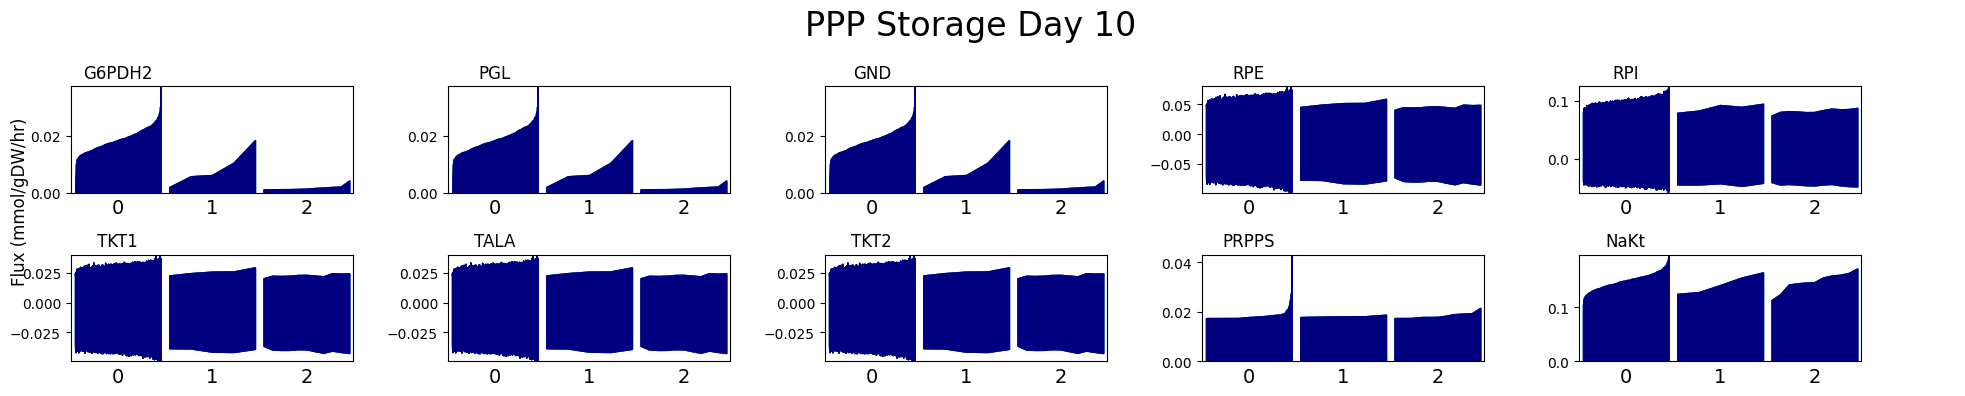

In [24]:
flux_optimization_viz.alleles_day_flux_small_multiples(
    10, flux_group_ppp, "PPP", figsize=(20, 4), flux_plots_path=flux_plots_path
);

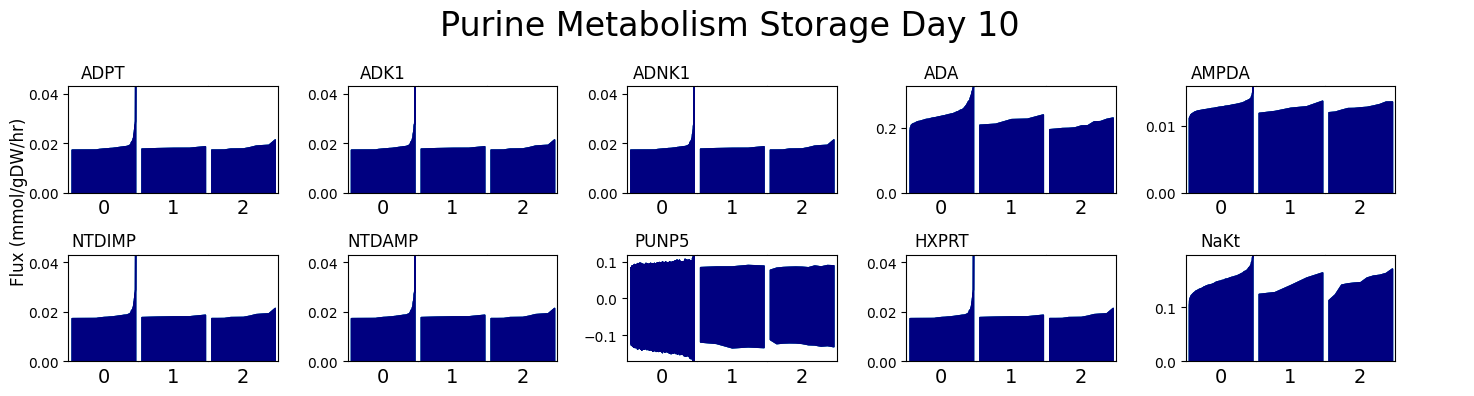

In [25]:
flux_optimization_viz.alleles_day_flux_small_multiples(
    10, flux_group_purine_metabolism, "Purine Metabolism", figsize=(15, 4), flux_plots_path=flux_plots_path
);

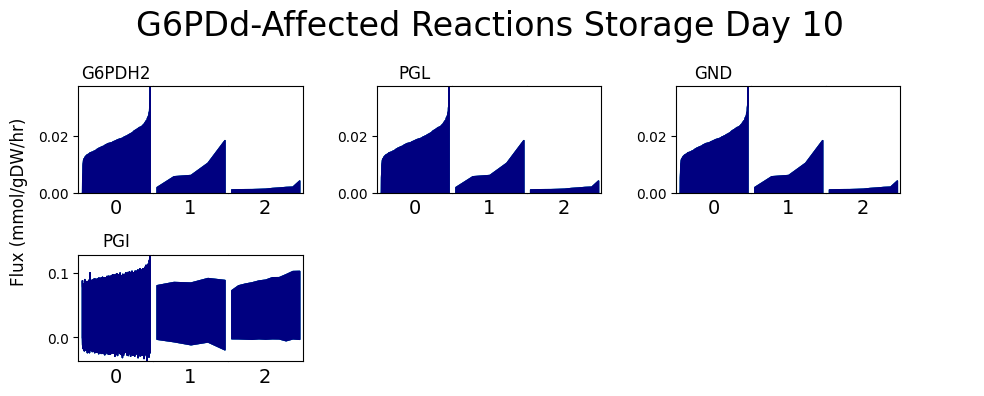

In [26]:
flux_optimization_viz.alleles_day_flux_small_multiples(
    10, flux_group_interesting_reactions, "G6PDd-Affected Reactions", figsize=(10, 4), flux_plots_path=flux_plots_path
);

In [27]:
flux_plots_path

WindowsPath('D:/Projects/RBC-GEM-akey7/data/processed/RBC3P_expanded/OVERLAY/RBComics_G6PD/flux_plots')

In [28]:
flux_optimization_viz.df_pcfva_alleles.head()

minimum   maximum     range
G6PD_alleles day reactions optimum                             
0            10  ADA       0.0          0.0  0.257065  0.257065
                           0.0          0.0  0.268406  0.268406
                           0.0          0.0  0.222184  0.222184
                           0.0          0.0  0.242309  0.242309
                           0.0          0.0  0.232688  0.232688